In [1]:
import Kea
from Kea.utils import plotting, funcs
from Kea.simulator import fbm
from Kea.statistics import statistics_base, moments
from Kea.statistics.spectra import strfn_spectra, spectra_base, arevalo_spectra, per_spectra
from Kea.statistics.statfunc import strfn, statfunc_base, statfunc_mpi_naive
from Kea.fitting import fit_base

c = plotting.COLOR_CYCLE_6

import matplotlib as mpl
plotting.modify_rc()
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

import numpy as np


In [5]:
from scipy.special import jv
import sympy as sp
sp.init_printing(use_latex='mathjax')

k = sp.symbols('k', postive=True, real=True)

sp_D = sp.symbols('D', positive=True, integer=True)
sp_D = 2

sp_L = sp.symbols('L', positive=True, real=True)
sp_L = 5*sp.pi
sp_N = sp.symbols('N', positive=True, integer=True)
sp_N = 256

sp_kmin = (sp.S(2)*sp.pi/sp_L)
sp_kmax = (sp.pi*sp_N/sp_L)

b = sp_kmin

sp_E = sp.exp(-k/b)

norm = sp.S(1)/(sp.S(2)*sp.pi)**sp_D

sig = norm * sp.integrate(sp.S(2) * (sp.S(2) * sp.pi * k * sp_E), (k, 0, sp.oo))
Ef = sp_E / sig

s = sp.symbols('sigma', real=True, positive=True)
xi = sp.symbols('xi', real=True, positive=True)

Hk = k**2 * s**2 * xi * sp.exp(- k**2 * s**2 / 2)

S_D = sp.S(2)*sp.pi**(sp_D/2)/sp.gamma(sp_D/2)

Vs_num = sp.S(2) * norm * sp.integrate((S_D * k**(sp_D-1)) * Ef * sp.Abs(Hk)**2, (k, 0, sp.oo))

Vs_denom = sp.S(2) * norm * sp.integrate((S_D * k**(sp_D-1)) * sp.Abs(Hk)**2, (k, 0, sp.oo))
Vs = Vs_num / Vs_denom

display(Vs.simplify())


                   ⎛                      2                                   
                   ⎜               65536⋅σ                                    
                   ⎜               ────────   ⎛       2  ⅈ⋅π⎞                 
            1.0  6 ⎜            4     25      ⎜65536⋅σ ⋅ℯ   ⎟            2    
8589934592⋅π   ⋅σ ⋅⎜4294967296⋅σ ⋅ℯ        ⋅Ei⎜─────────────⎟ + 1638400⋅σ  - 2
                   ⎝                          ⎝      25     ⎠                 
──────────────────────────────────────────────────────────────────────────────
                                                                   28147497671

         ⎛          2                             ⎞         2      ⎞          
         ⎜       4⋅σ                              ⎟  65532⋅σ       ⎟  -65536⋅σ
         ⎜       ────   ⎛   2  ⅈ⋅π⎞               ⎟  ────────      ⎟  ────────
         ⎜    4   25    ⎜4⋅σ ⋅ℯ   ⎟        2      ⎟     25         ⎟      25  
68435456⋅⎜16⋅σ ⋅ℯ    ⋅Ei⎜─────────⎟ + 100⋅σ  - 625⎟

In [6]:
display(sp.limit(Vs.simplify(), s, sp.oo))
display(sp.limit(Vs.simplify(), s, 0))

display(sp.limit(Vs.simplify(), s, np.sqrt(2.*sp_D + 6.)/(2.*sp_kmin)).evalf())
display(sp.limit(Vs.simplify(), s, np.sqrt(2.*sp_D + 6.)/(2.*19.)).evalf())

NotImplementedError: Result depends on the sign of sign(exp_polar(I*pi) + 1)

NameError: name 'exp_polar' is not defined

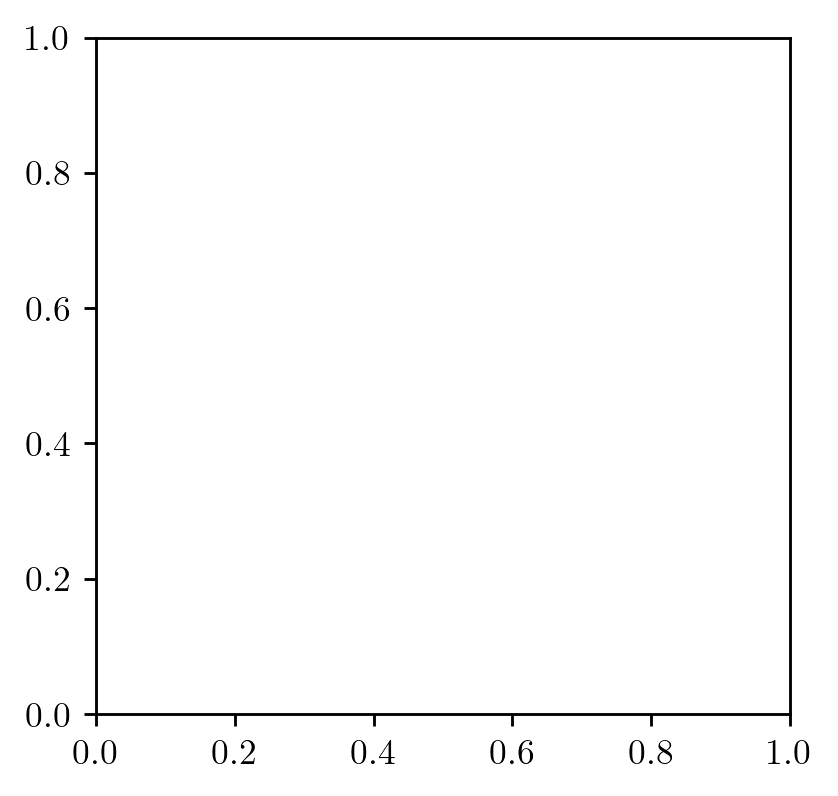

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(3.5, 3.5), dpi=256)

lam_E = sp.lambdify(k, Ef, modules=['mpmath'])
lam_V = sp.lambdify(s, Vs, modules=['mpmath'])

for _k in np.exp(np.linspace(np.log(float(sp_kmin.evalf())), np.log(float(sp_kmax.evalf())), 100)):

    if _k > 4.87:
        continue

    _s = np.sqrt(2.)/_k
    num = lam_V(float(_s))
    denom = lam_E(float(_k))
    print(_k, _s, num)
    ax.scatter(_k, np.abs(num), marker='o', s=5., color=c[0], zorder=2, linewidth=0.2, edgecolor='black')

    _s = np.sqrt(2.*sp_D + 6.)/(2.*_k)
    num = lam_V(float(_s))
    ax.scatter(_k, num, marker='o', s=5., color=c[1], zorder=2, linewidth=0.2, edgecolor='black')

    ax.scatter(_k, denom, marker='X', s=5., color=c[2], zorder=0, linewidth=0.2, edgecolor='black')

ax.loglog()

ax.axvline(float(sp_kmin.evalf()), color='black', linewidth=1., linestyle=(0,(5,5)), zorder=0)
ax.axvline(float(sp_kmax.evalf()), color='black', linewidth=1., linestyle=(0,(5,5)), zorder=0)

ax.axvline(b.evalf(), color='gray', linewidth=1., linestyle=':', zorder=0)

ax.set_ylabel('Bias, $\\tilde{E}(k_{\sigma})/E(k)$')
ax.set_xlabel('Wavenumber, $k_{\sigma}$')